In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
  

In [2]:
import sklearn.datasets 

cancer_data = sklearn.datasets.load_breast_cancer() 

In [3]:
cancer_data_df = pd.DataFrame(cancer_data.data , columns= cancer_data.feature_names ) 

In [4]:
cancer_data_df['target'] = cancer_data.target

In [5]:
cancer_data_df.head(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0


In [6]:
X = cancer_data_df.drop( columns= 'target' , axis= 1 ) 
y = cancer_data_df['target'] 

In [7]:
from sklearn.model_selection import train_test_split 

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state=2 ) 



In [8]:
print(X.shape  , X_train.shape , X_test.shape ) 


(569, 30) (455, 30) (114, 30)


In [9]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()

X_trainS = scaler.fit_transform(X_train) 
X_testS  = scaler.transform(X_test)

In [10]:
# =======================================================

In [11]:
import tensorflow as tf 
# tf.random.set_seed(3)


In [12]:
def set_random_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

In [13]:
from tensorflow import keras 
import random 

set_random_seeds(3)
model = keras.Sequential([

    keras.layers.Flatten(input_shape=(30,)) , 
    keras.layers.Dense(20, activation='relu') ,
    keras.layers.Dropout(0.3), 
    keras.layers.Dense(10, activation='relu') ,
    keras.layers.Dense(2, activation='sigmoid') 
    
    
]) 


c:\Users\M7MD\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(

    optimizer='adam' ,
    loss= 'sparse_categorical_crossentropy' , 
    metrics=['accuracy'] 
    
    
)

In [15]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='accuracy', 
    patience=3,  
    restore_best_weights=True  
)

In [16]:

nModel = model.fit(
    X_trainS, y_train,
    validation_split=0.1, 
    epochs=50,  
    batch_size=32,
    callbacks=[early_stopping]  
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4792 - loss: 0.7364 - val_accuracy: 0.8696 - val_loss: 0.5292
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6834 - loss: 0.5797 - val_accuracy: 0.9130 - val_loss: 0.4417
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8445 - loss: 0.4573 - val_accuracy: 0.9130 - val_loss: 0.3564
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9085 - loss: 0.3911 - val_accuracy: 0.9565 - val_loss: 0.2841
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9021 - loss: 0.3388 - val_accuracy: 0.9565 - val_loss: 0.2275
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9411 - loss: 0.2644 - val_accuracy: 0.9565 - val_loss: 0.1859
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9386 - loss: 0.2270 - val_accuracy: 0.9565 - val_loss: 0.1568
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9488 - loss: 0.2092 - val_accuracy: 0.9565 - val_loss

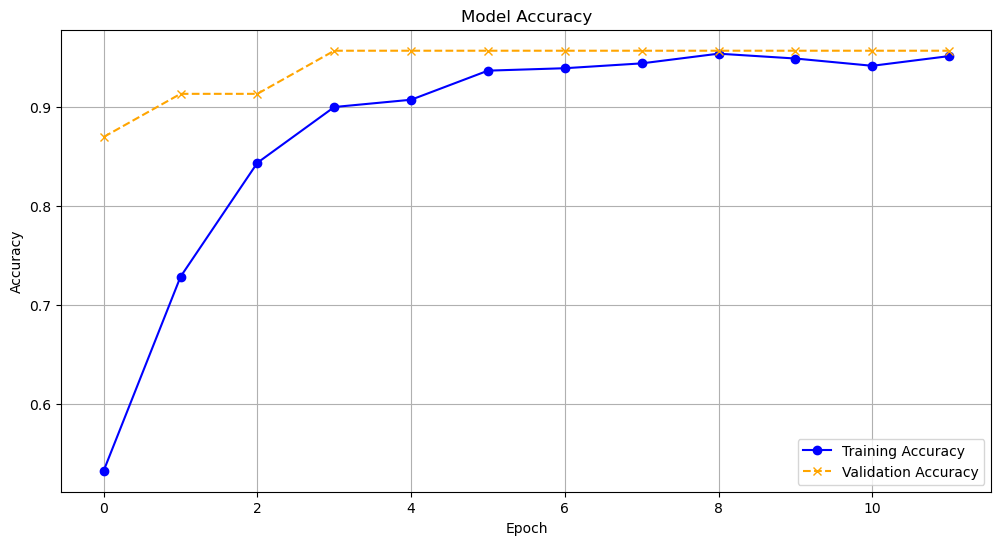

In [17]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 1, 1) 
plt.plot(nModel.history['accuracy'], label='Training Accuracy', color='blue', linestyle='-', marker='o')
plt.plot(nModel.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--', marker='x')
plt.title('Model Accuracy')
plt.ylabel('Accuracy') 
plt.xlabel('Epoch') 
plt.legend(loc='lower right')
plt.grid(True)

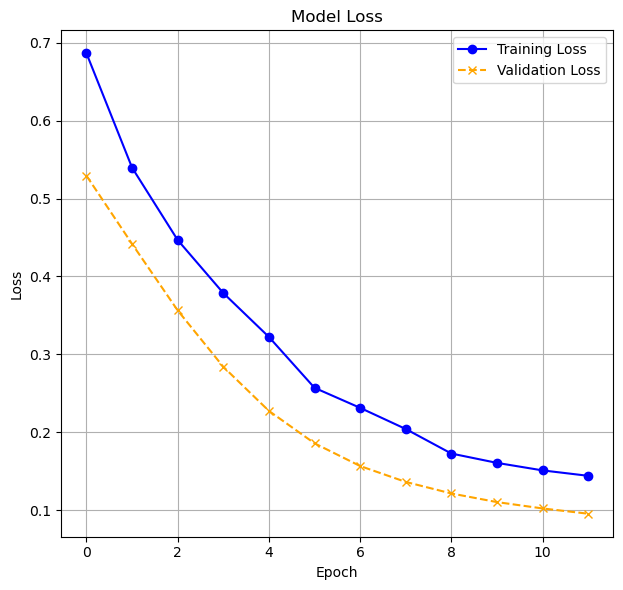

In [18]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)  # تقسيم الرسم إلى 1 صف، 2 أعمدة، الرسم الثاني
plt.plot(nModel.history['loss'], label='Training Loss', color='blue', linestyle='-', marker='o')
plt.plot(nModel.history['val_loss'], label='Validation Loss', color='orange', linestyle='--', marker='x')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch') 
plt.legend(loc='upper right')
plt.grid(True)

# عرض الرسومات
plt.tight_layout()
plt.show() 

In [19]:
loss , accuracy = model.evaluate(X_testS , y_test , verbose=0 )
print('accuracy' , accuracy , 'loss' , loss ) 

accuracy 0.9385964870452881 loss 0.15522544085979462


In [20]:
Ypred = model.predict(X_testS)
Ypred[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([0.28636047, 0.31028098], dtype=float32)

In [21]:
YpredL = np.argmax(Ypred, axis=1)
print(YpredL)

[1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1
 1 1 1 0 0 1 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0
 1 0 1 1 1 1 0 0 0 1 1 0 1 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 1 0
 0 1 0]


In [22]:
def predict_breast_cancer(input_data):


    try:
    
        if len(input_data) != 30:
            raise ValueError("Input data must contain exactly 30 features.")

        array = np.array(input_data).reshape(1, -1)
        
        scaled_data = scaler.transform(array)
        
        prediction = model.predict(scaled_data)
        
        predicted_class = np.argmax(prediction)
        
        if predicted_class == 0:
            return "Malignant"
        else:
            return "Benign"
            
    except ValueError as e:
        return f"Error: {e}"
    except Exception as e:
        return f"An unexpected error occurred: {e}"


In [23]:
input_data = (11.99, 10.35, 122.8, 1001, 0.1184, 0.2776, 0.3001, 0.1471, 0.2419, 0.07871, 
              1.095, 0.9053, 8.589, 153.4, 0.006399, 0.04904, 0.05373, 0.01587, 0.03003, 
              0.006193, 25.38, 17.33, 184.6, 2019, 0.1622, 0.6656, 0.7119, 0.2654, 
              0.4601, 0.1189)

result = predict_breast_cancer(input_data)
print(result) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Malignant


c:\Users\M7MD\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
